#Quantum Computing: Quantum Teleportation Protocol
#Study notes by Gabriel Velázquez

In [ ]:
!pip install qiskit qiskit-aer pylatexenc

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

# Publish-quality dark mode styling
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.facecolor': '#121212',
    'figure.facecolor': '#121212'
})

The no-cloning theorem dictates that an arbitrary unknown quantum state cannot be perfectly copied. However, by leveraging quantum entanglement and classical communication, we can transfer a state from one qubit to another, destroying the original in the process.


---



## Qubit Configuration

The teleportation protocol requires **three qubits**:

* **Qubit 0 ($A$):** Alice's data qubit, holding the unknown state:
  $$\vert\psi\rangle = \alpha\vert 0\rangle + \beta\vert 1\rangle$$

* **Qubit 1 ($B$):** Alice's half of the entangled EPR pair.

* **Qubit 2 ($C$):** Bob's half of the entangled EPR pair.


---



## Step 1: Initialization and EPR Pair Creation

We initialize the system with **Qubit $A$** holding our state, and **Qubits $B$ and $C$** in $\vert 0\rangle$.

The preparation of the Bell state $\vert\Phi^+\rangle$ involves applying a **Hadamard ($H$) gate** to the first qubit, followed by a **Controlled-NOT ($CX$) gate**:

1. Apply **$H$** on Qubit $B$.
2. Apply **$CX$** with control on Qubit $B$ and target on Qubit $C$.

This creates the maximally entangled Bell state:

$$\vert\Psi_1\rangle = \vert\psi\rangle_A \otimes \vert\Phi^+\rangle_{BC} = \frac{1}{\sqrt{2}} (\alpha\vert 0\rangle_A + \beta\vert 1\rangle_A) \otimes (\vert 00\rangle_{BC} + \vert 11\rangle_{BC})$$

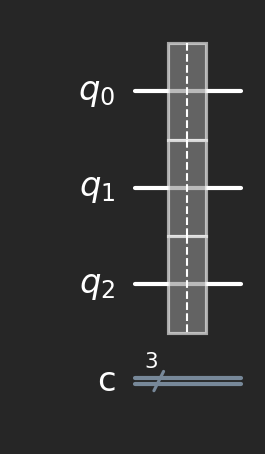

In [2]:
qr = QuantumRegister(3, name="q")
cr = ClassicalRegister(3, name="c")
step_circuit = QuantumCircuit(qr, cr)
step_circuit.barrier()

display(step_circuit.draw(output='mpl', style='iqp-dark'))

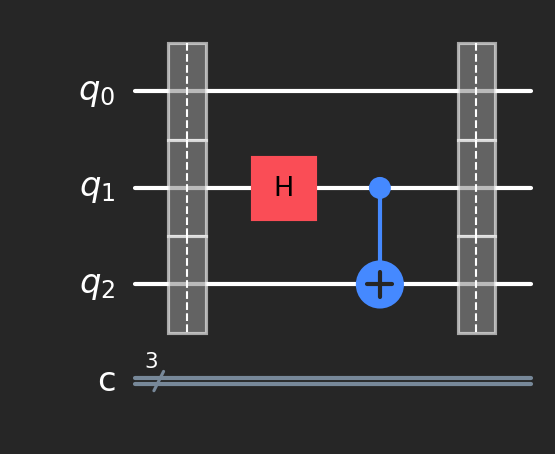

In [3]:
step_circuit.h(1)
step_circuit.cx(1, 2)
step_circuit.barrier()

display(step_circuit.draw(output='mpl', style='iqp-dark'))

# Step 2: Alice's Entangling Operations
Alice applies a CNOT gate with $A$ as control and $B$ as target. Expanding the tensor product yields:
  $$\vert{}\Psi_2\rangle = \frac{1}{\sqrt{2}} \left[ \alpha\vert{}0\rangle_A (\vert{}00\rangle_{BC} + \vert{}11\rangle_{BC}) + \beta\vert{}1\rangle_A (\vert{}10\rangle_{BC} + \vert{}01\rangle_{BC}) \right]$$Alice then applies a Hadamard gate to $A$. This maps $\vert{}0\rangle \to \frac{\vert{}0\rangle + \vert{}1\rangle}{\sqrt{2}}$ and $\vert{}1\rangle \to \frac{\vert{}0\rangle - \vert{}1\rangle}{\sqrt{2}}$:
  $$\vert{}\Psi_3\rangle = \frac{1}{2} \left[ \alpha(\vert{}0\rangle_A + \vert{}1\rangle_A) \otimes (\vert{}00\rangle_{BC} + \vert{}11\rangle_{BC}) + \beta(\vert{}0\rangle_A - \vert{}1\rangle_A) \otimes (\vert{}10\rangle_{BC} + \vert{}01\rangle_{BC}) \right]$$

#Step 3: Regrouping in the Computational Basis
To understand the measurement outcomes, we factor the state by Alice's qubits ($A$ and $B$):$$\vert{}\Psi_3\rangle = \frac{1}{2} \big[ \vert{}00\rangle_{AB}(\alpha\vert{}0\rangle_C + \beta\vert{}1\rangle_C) + \vert{}01\rangle_{AB}(\alpha\vert{}1\rangle_C + \beta\vert{}0\rangle_C) + \vert{}10\rangle_{AB}(\alpha\vert{}0\rangle_C - \beta\vert{}1\rangle_C) + \vert{}11\rangle_{AB}(\alpha\vert{}1\rangle_C - \beta\vert{}0\rangle_C) \big]$$

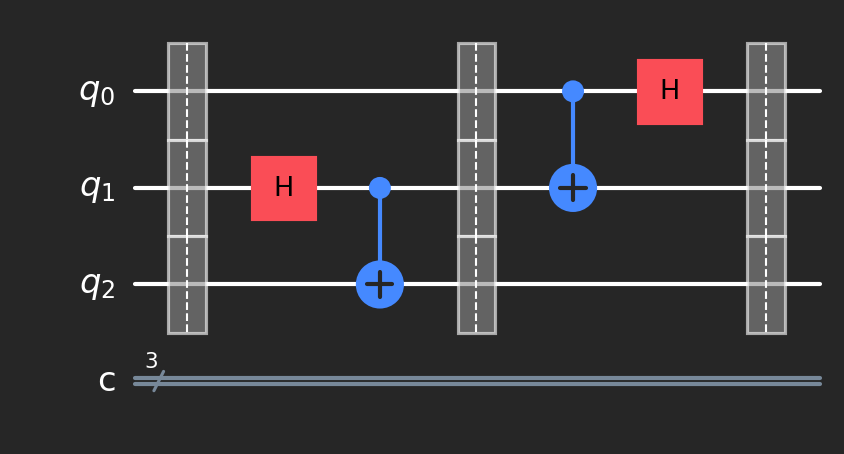

In [4]:
step_circuit.cx(0, 1)
step_circuit.h(0)
step_circuit.barrier()

display(step_circuit.draw(output='mpl', style='iqp-dark'))

## Step 4: Measurement and Conditional Pauli Corrections

Alice measures **qubits 0 and 1**, storing the results in **classical bits 0 and 1**. The superposition collapses, leaving Bob's qubit ($C$) in one of four possible states.

To recover the initial state $\vert\psi\rangle$, Bob applies conditional Pauli corrections:

* **`00`**: Bob applies $I$
  $$\alpha\vert 0\rangle + \beta\vert 1\rangle$$

* **`01`**: Bob applies $X$
  $$\alpha\vert 1\rangle + \beta\vert 0\rangle \xrightarrow{\ X\ } \alpha\vert 0\rangle + \beta\vert 1\rangle$$

* **`10`**: Bob applies $Z$
  $$\alpha\vert 0\rangle - \beta\vert 1\rangle \xrightarrow{\ Z\ } \alpha\vert 0\rangle + \beta\vert 1\rangle$$

* **`11`**: Bob applies $ZX$
  $$\alpha\vert 1\rangle - \beta\vert 0\rangle \xrightarrow{\ X\ } \alpha\vert 0\rangle - \beta\vert 1\rangle \xrightarrow{\ Z\ } \alpha\vert 0\rangle + \beta\vert 1\rangle$$

---

### Quantum Circuit Implementation

To achieve these corrections automatically within a circuit:

1. A **CNOT gate** is applied (controlled by qubit 1, targeting qubit 2).
2. A **CZ gate** is applied (controlled by qubit 0, targeting qubit 2).

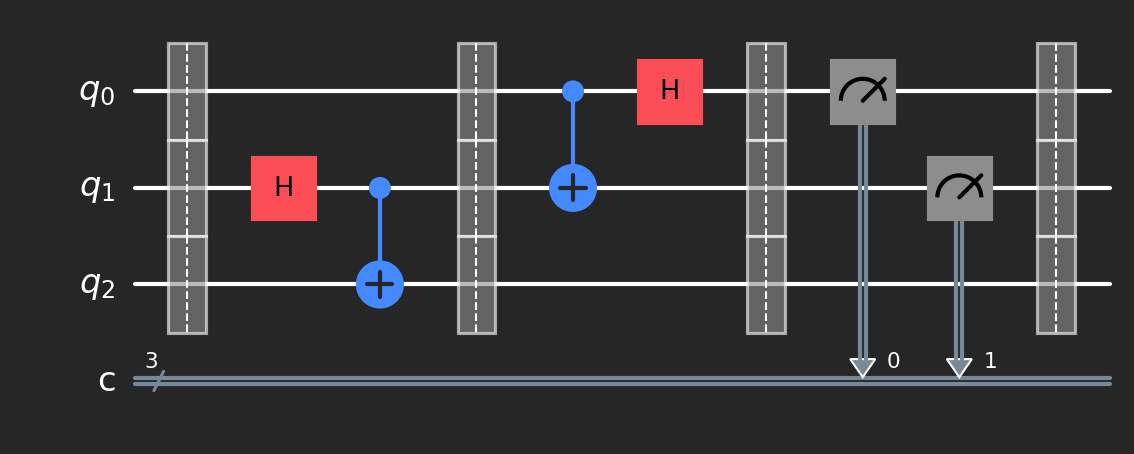

In [5]:
step_circuit.measure([0, 1], [0, 1])
step_circuit.barrier()

display(step_circuit.draw(output='mpl', style='iqp-dark'))

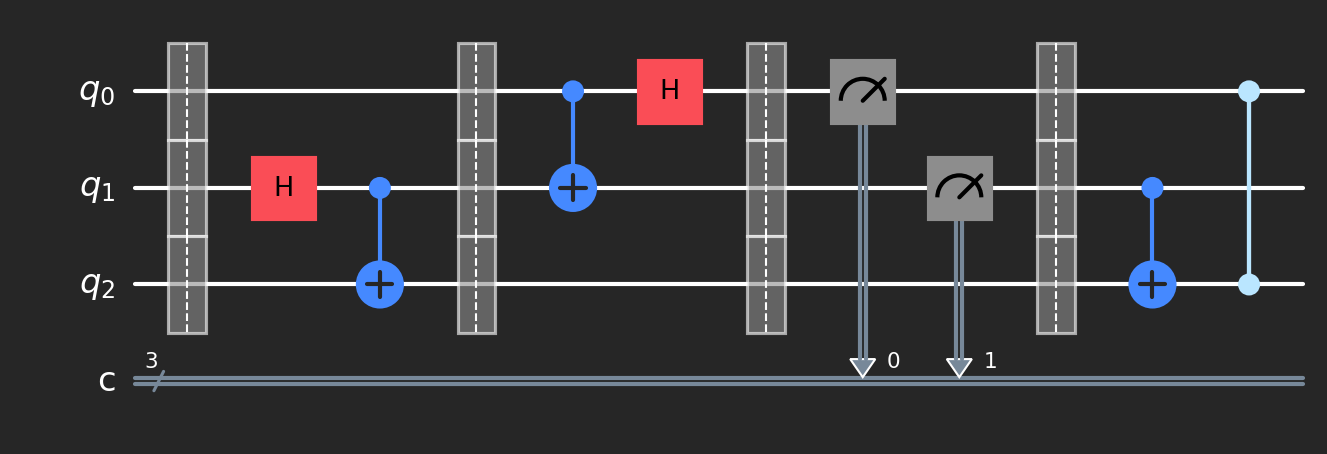

In [6]:
step_circuit.cx(1, 2)
step_circuit.cz(0, 2)

display(step_circuit.draw(output='mpl', style='iqp-dark'))

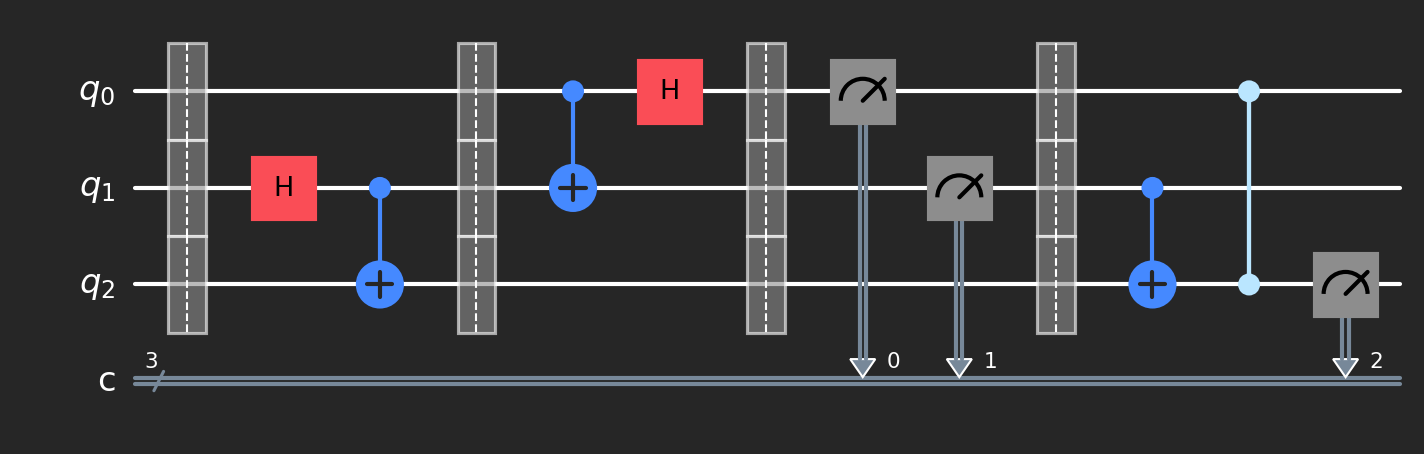

In [7]:
step_circuit.measure([2], [2])

display(step_circuit.draw(output='mpl', style='iqp-dark'))

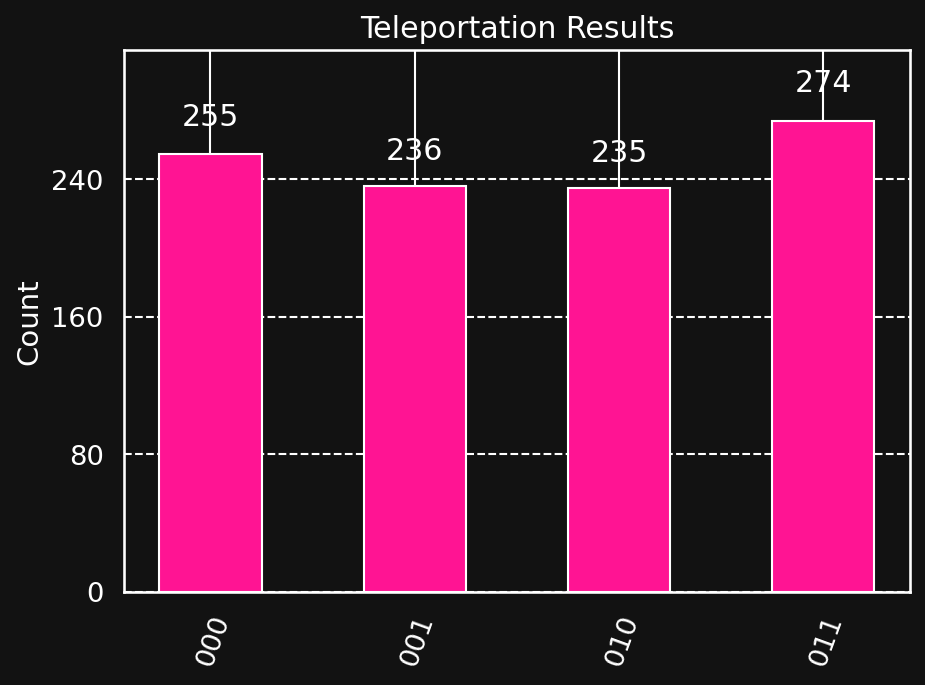

In [13]:
def simulate_and_visualize(circuit: QuantumCircuit, shots: int = 1000):
    """
    Executes the given circuit on a QASM simulator and plots the outcome.

    Args:
        circuit (QuantumCircuit): The circuit to run.
        shots (int): Number of experimental shots.
    """
    # Use backend.run() instead of the deprecated execute() function
    simulator = Aer.get_backend('qasm_simulator')
    job = simulator.run(circuit, shots=shots)
    result = job.result()
    counts = result.get_counts(circuit)

    # Generate the probability histogram
    fig = plot_histogram(counts, title="Teleportation Results", color='#ff1493')

    # Apply matching dark theme configuration to the resulting figure
    fig.patch.set_facecolor('#121212')
    for ax in fig.axes:
        ax.set_facecolor('#121212')
        # Set labels and title to white
        ax.title.set_color('white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
        ax.tick_params(axis='x', colors='white')
        ax.tick_params(axis='y', colors='white')

        # Adjust the top margin to prevent number overlap
        ax.set_ylim(0, max(counts.values()) * 1.15)

        # Update text inside the plot to white
        for text in ax.texts:
            text.set_color('white')

    display(fig)

# Run the simulation using the active circuit variable 'step_circuit'
simulate_and_visualize(step_circuit)